In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
eda_df = pd.read_excel(
    "cleaned_personalized_healthcare_data.xlsx",
    sheet_name="Cleaned_Data"
)

print("EDA dataset loaded successfully")
print("Dataset shape:", eda_df.shape)
print("\nColumns:")
print(eda_df.columns.tolist())

eda_df.head()

EDA dataset loaded successfully
Dataset shape: (500, 15)

Columns:
['patient_id', 'age_years', 'sex', 'condition', 'glucose_mg_dl', 'systolic_bp_mmhg', 'diastolic_bp_mmhg', 'cholesterol_mg_dl', 'heart_rate_bpm', 'recorded_allergy', 'family_history', 'adherence_level', 'historical_medication_class', 'recorded_outcome', 'data_quality_status']


,patient_id,age_years,sex,condition,glucose_mg_dl,systolic_bp_mmhg,diastolic_bp_mmhg,cholesterol_mg_dl,heart_rate_bpm,recorded_allergy,family_history,adherence_level,historical_medication_class,recorded_outcome,data_quality_status
0,SYN-0001,28,Female,Seasonal Allergy,97,132,85,214,73,None recorded,No,High,Antihistamine class A,Improved,Valid
1,SYN-0002,80,Female,Acid Reflux,80,123,79,189,59,None recorded,Yes,Medium,Acid-suppression class A,Improved,Valid
2,SYN-0003,36,Female,Asthma,86,121,66,192,82,None recorded,No,Medium,Controller inhaler class,Follow-up required,Valid
3,SYN-0004,21,Male,High Cholesterol,103,120,69,278,85,None recorded,Yes,High,Lipid-lowering class B,Follow-up required,Valid
4,SYN-0005,58,Male,High Cholesterol,79,111,76,244,64,None recorded,Yes,High,Lipid-lowering class B,Follow-up required,Valid


In [3]:
print("Numeric statistical summary:")
display(
    eda_df.describe().T
)

print("\nCategorical statistical summary:")
display(
    eda_df.describe(include="object").T
)

Numeric statistical summary:


,count,mean,std,min,25%,50%,75%,max
age_years,500.0,47.542,17.694135,18.0,32.0,46.5,62.00,80.0
glucose_mg_dl,500.0,108.362,35.043502,72.0,85.0,100.5,113.00,225.0
systolic_bp_mmhg,500.0,127.348,18.289338,103.0,114.0,125.0,135.00,189.0
diastolic_bp_mmhg,500.0,81.294,10.921269,65.0,72.0,81.0,87.00,118.0
cholesterol_mg_dl,500.0,197.442,39.046278,146.0,168.0,192.0,216.00,330.0
heart_rate_bpm,500.0,76.594,11.378757,58.0,67.0,76.0,86.25,96.0



Categorical statistical summary:


,count,unique,top,freq
patient_id,500,500,SYN-0001,1
sex,500,2,Male,254
condition,500,6,Seasonal Allergy,92
recorded_allergy,500,5,None recorded,392
family_history,500,2,No,266
adherence_level,500,3,High,177
historical_medication_class,500,12,Antihistamine class A,52
recorded_outcome,500,3,Follow-up required,172
data_quality_status,500,2,Valid,381


In [4]:
numeric_columns = [
    "age_years",
    "glucose_mg_dl",
    "systolic_bp_mmhg",
    "diastolic_bp_mmhg",
    "cholesterol_mg_dl",
    "heart_rate_bpm"
]

categorical_columns = [
    "sex",
    "condition",
    "recorded_allergy",
    "family_history",
    "adherence_level",
    "historical_medication_class",
    "recorded_outcome"
]

print("Numeric columns:", numeric_columns)
print("\nCategorical columns:", categorical_columns)

Numeric columns: ['age_years', 'glucose_mg_dl', 'systolic_bp_mmhg', 'diastolic_bp_mmhg', 'cholesterol_mg_dl', 'heart_rate_bpm']

Categorical columns: ['sex', 'condition', 'recorded_allergy', 'family_history', 'adherence_level', 'historical_medication_class', 'recorded_outcome']


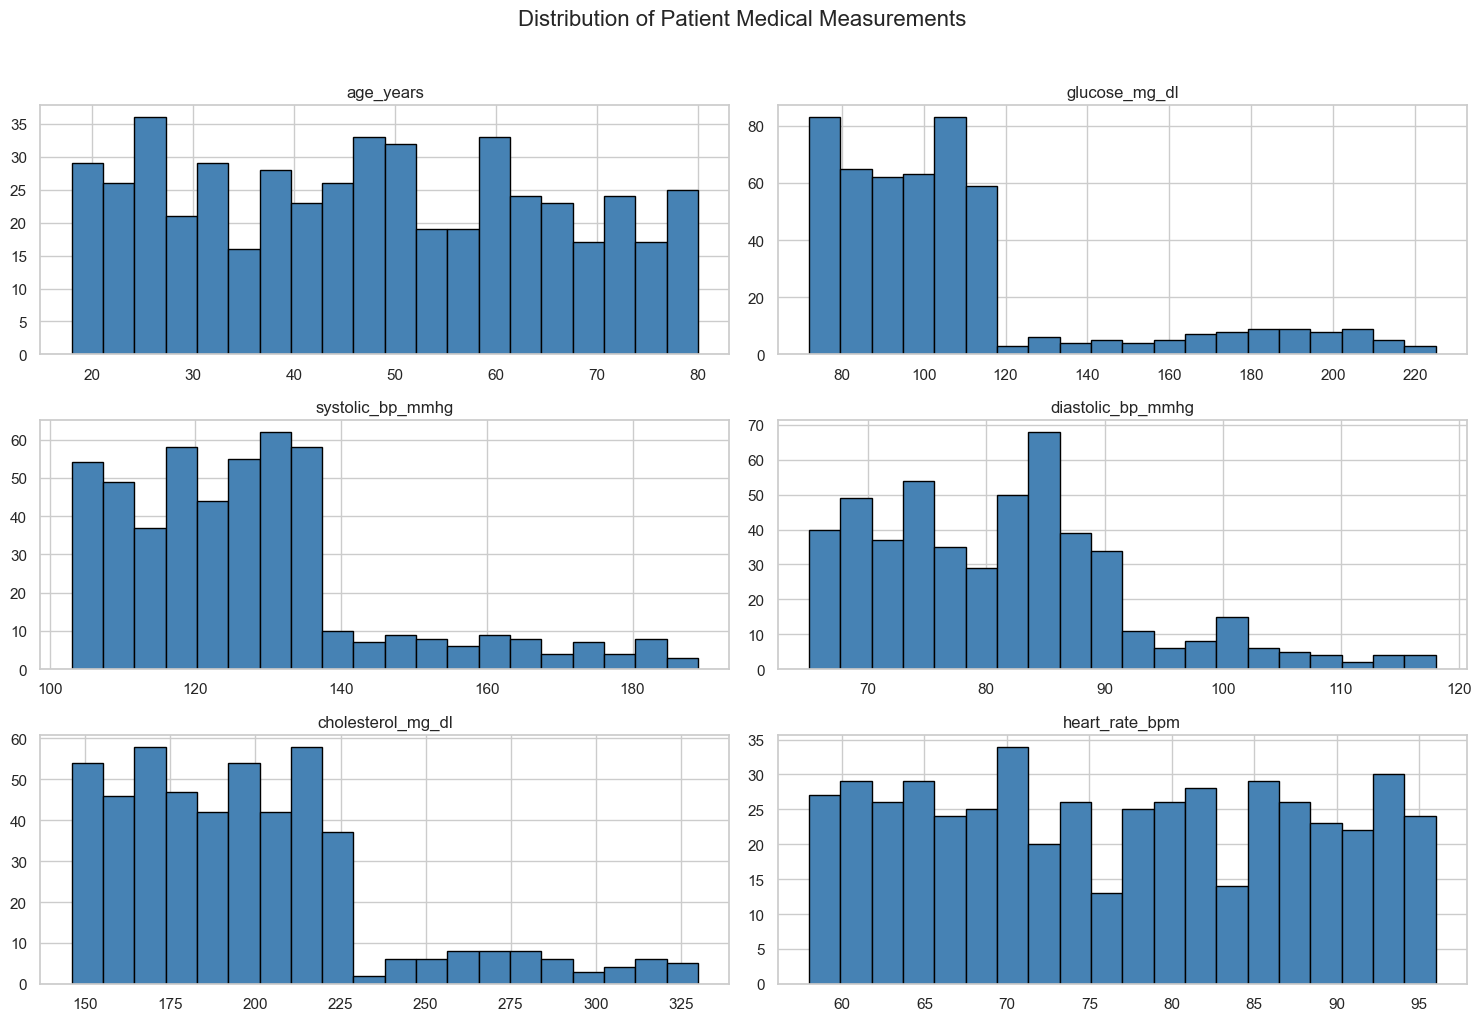

In [5]:
eda_df[numeric_columns].hist(
    figsize=(15, 10),
    bins=20,
    color="steelblue",
    edgecolor="black"
)

plt.suptitle(
    "Distribution of Patient Medical Measurements",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

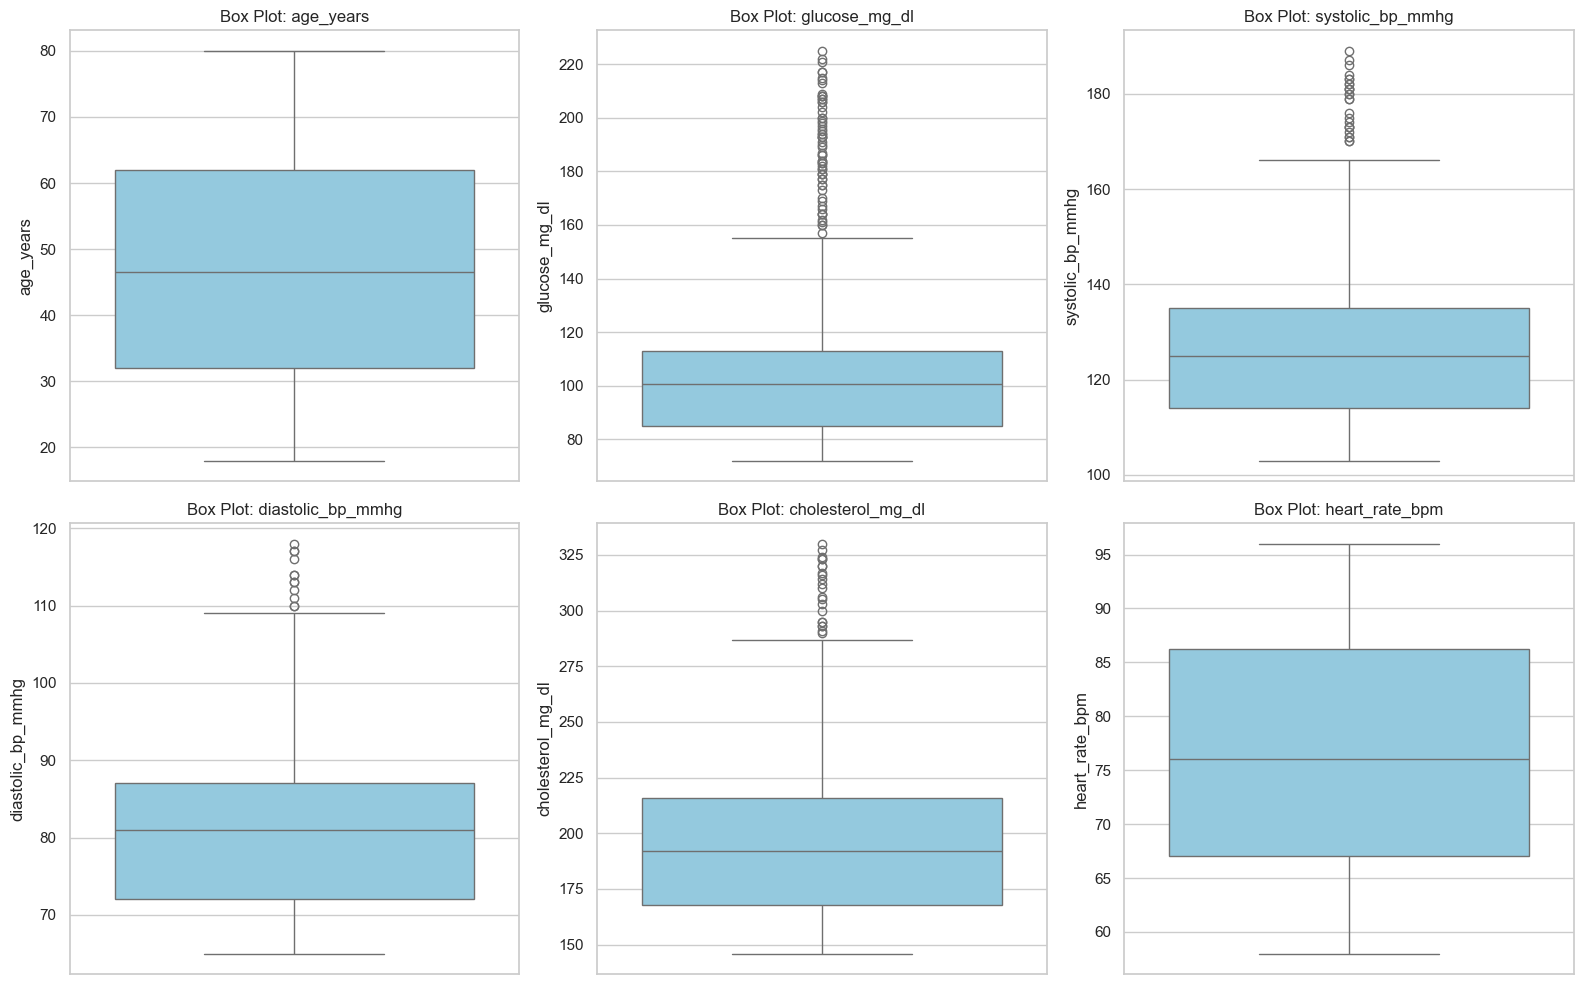

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes = axes.flatten()

for index, column in enumerate(numeric_columns):
    sns.boxplot(
        y=eda_df[column],
        ax=axes[index],
        color="skyblue"
    )

    axes[index].set_title(f"Box Plot: {column}")
    axes[index].set_ylabel(column)

plt.tight_layout()
plt.show()

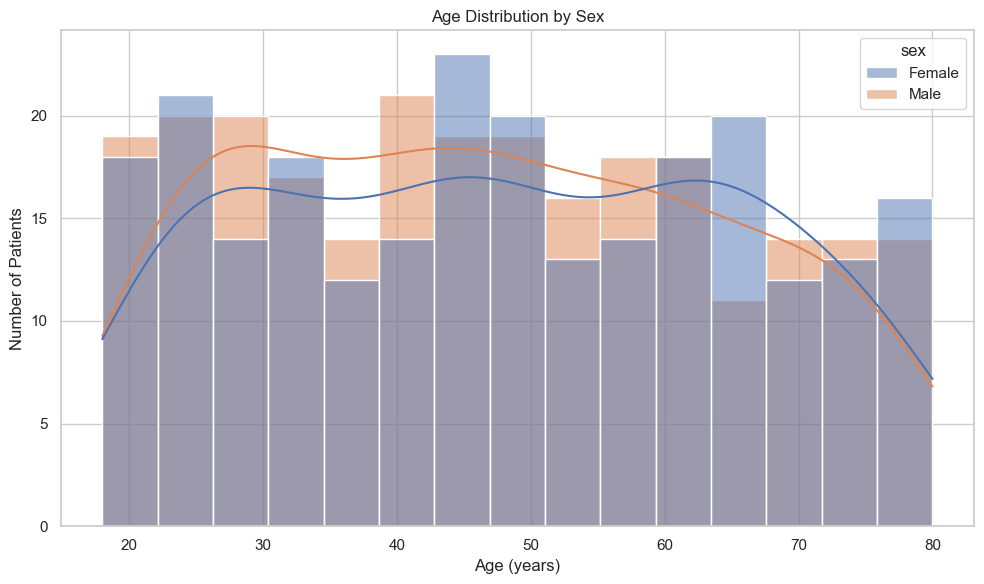

In [7]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=eda_df,
    x="age_years",
    hue="sex",
    bins=15,
    kde=True,
    multiple="layer",
    alpha=0.5
)

plt.title("Age Distribution by Sex")
plt.xlabel("Age (years)")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

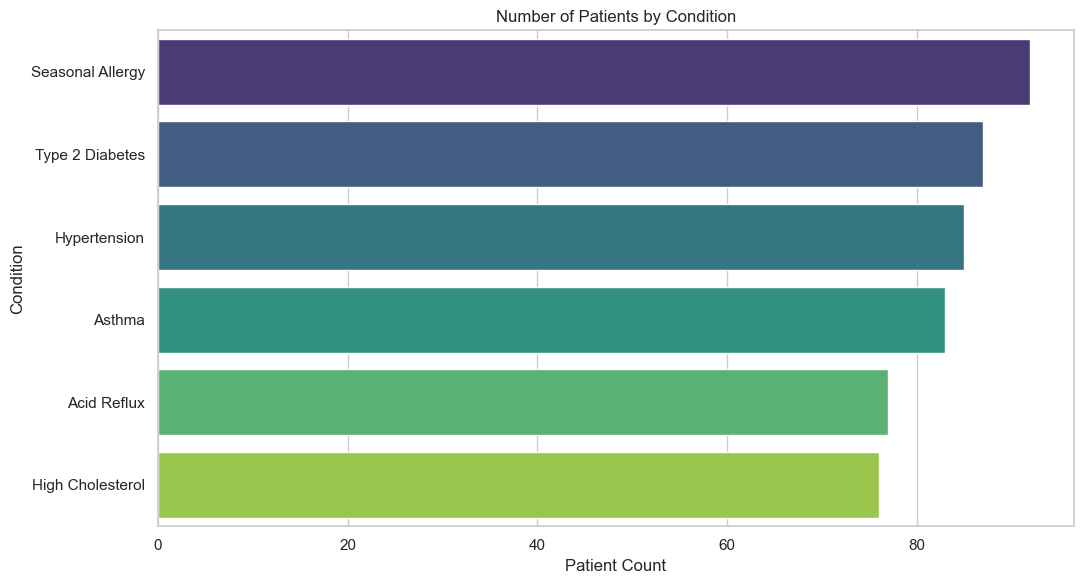

In [8]:
condition_counts = (
    eda_df["condition"]
    .value_counts()
    .reset_index()
)

condition_counts.columns = ["condition", "patient_count"]

condition_counts

plt.figure(figsize=(11, 6))

sns.barplot(
    data=condition_counts,
    x="patient_count",
    y="condition",
    hue="condition",
    palette="viridis",
    legend=False
)

plt.title("Number of Patients by Condition")
plt.xlabel("Patient Count")
plt.ylabel("Condition")

plt.tight_layout()
plt.show()

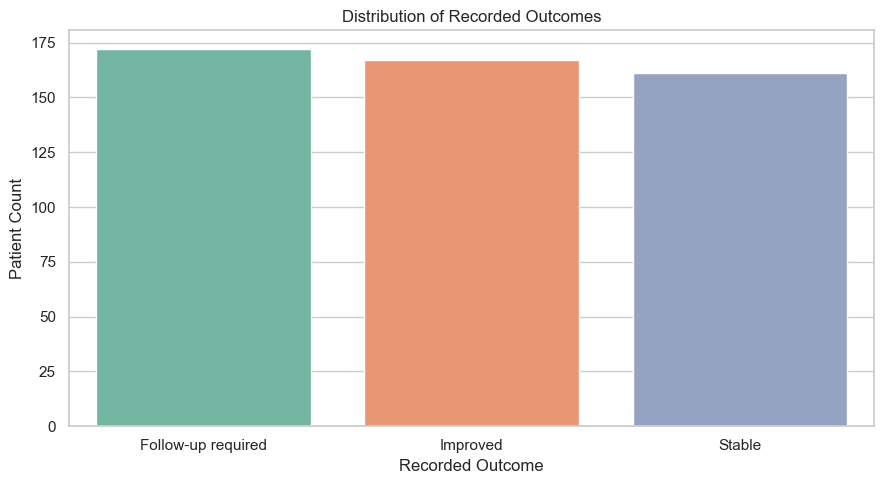

In [9]:
outcome_counts = (
    eda_df["recorded_outcome"]
    .value_counts()
    .reset_index()
)

outcome_counts.columns = ["recorded_outcome", "patient_count"]

outcome_counts

plt.figure(figsize=(9, 5))

sns.barplot(
    data=outcome_counts,
    x="recorded_outcome",
    y="patient_count",
    hue="recorded_outcome",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Recorded Outcomes")
plt.xlabel("Recorded Outcome")
plt.ylabel("Patient Count")

plt.tight_layout()
plt.show()

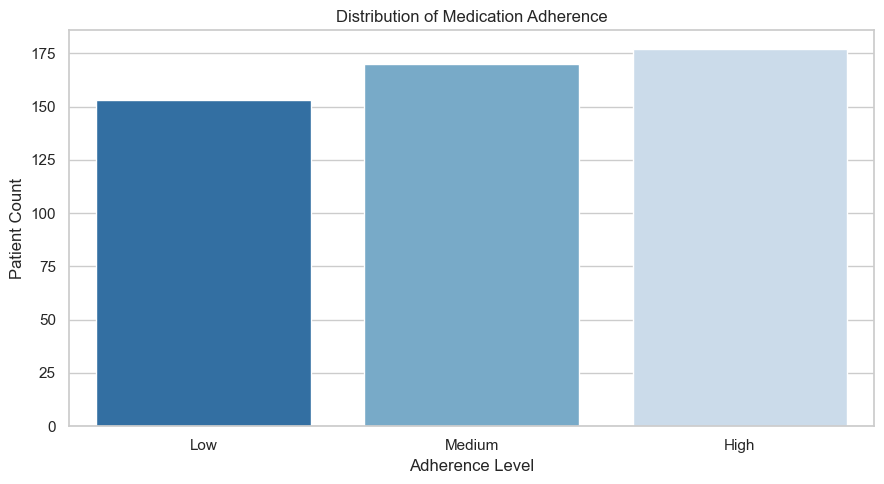

In [10]:
adherence_order = ["Low", "Medium", "High"]

plt.figure(figsize=(9, 5))

sns.countplot(
    data=eda_df,
    x="adherence_level",
    order=adherence_order,
    hue="adherence_level",
    palette="Blues",
    legend=False
)

plt.title("Distribution of Medication Adherence")
plt.xlabel("Adherence Level")
plt.ylabel("Patient Count")

plt.tight_layout()
plt.show()

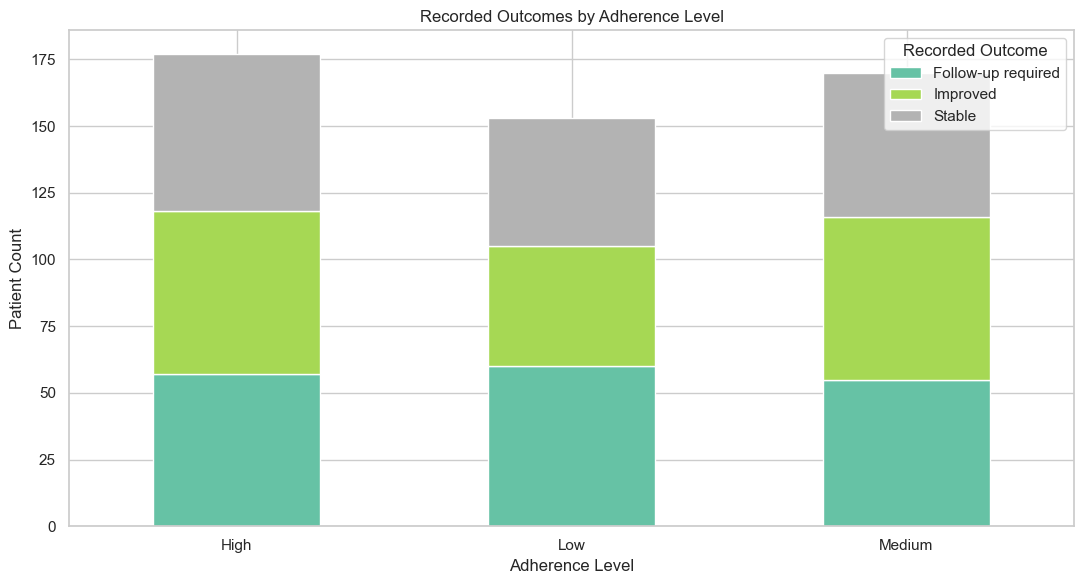

recorded_outcome,Follow-up required,Improved,Stable
adherence_level,,,
High,32.20,34.46,33.33
Low,39.22,29.41,31.37
Medium,32.35,35.88,31.76


In [11]:
adherence_outcome = pd.crosstab(
    eda_df["adherence_level"],
    eda_df["recorded_outcome"]
)

adherence_outcome

adherence_outcome.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    colormap="Set2"
)

plt.title("Recorded Outcomes by Adherence Level")
plt.xlabel("Adherence Level")
plt.ylabel("Patient Count")
plt.xticks(rotation=0)
plt.legend(title="Recorded Outcome")

plt.tight_layout()
plt.show()

adherence_outcome_percentage = pd.crosstab(
    eda_df["adherence_level"],
    eda_df["recorded_outcome"],
    normalize="index"
).mul(100).round(2)

adherence_outcome_percentage

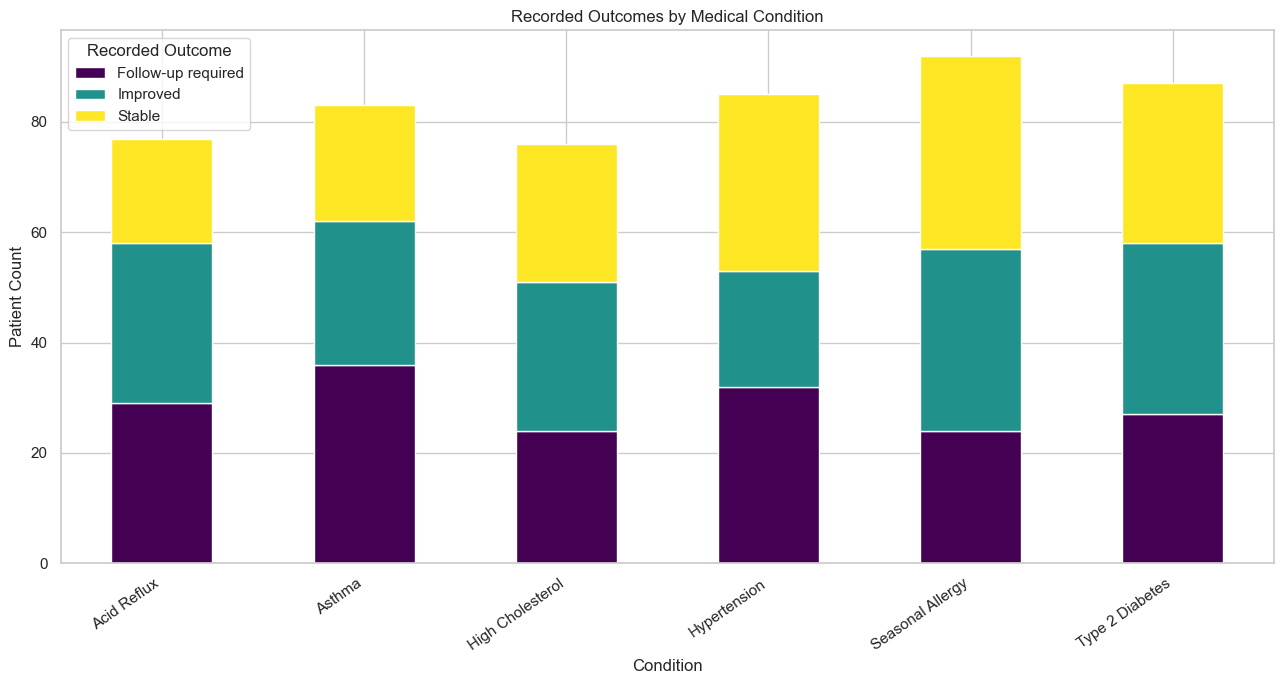

In [12]:
condition_outcome = pd.crosstab(
    eda_df["condition"],
    eda_df["recorded_outcome"]
)

condition_outcome

condition_outcome.plot(
    kind="bar",
    stacked=True,
    figsize=(13, 7),
    colormap="viridis"
)

plt.title("Recorded Outcomes by Medical Condition")
plt.xlabel("Condition")
plt.ylabel("Patient Count")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Recorded Outcome")

plt.tight_layout()
plt.show()

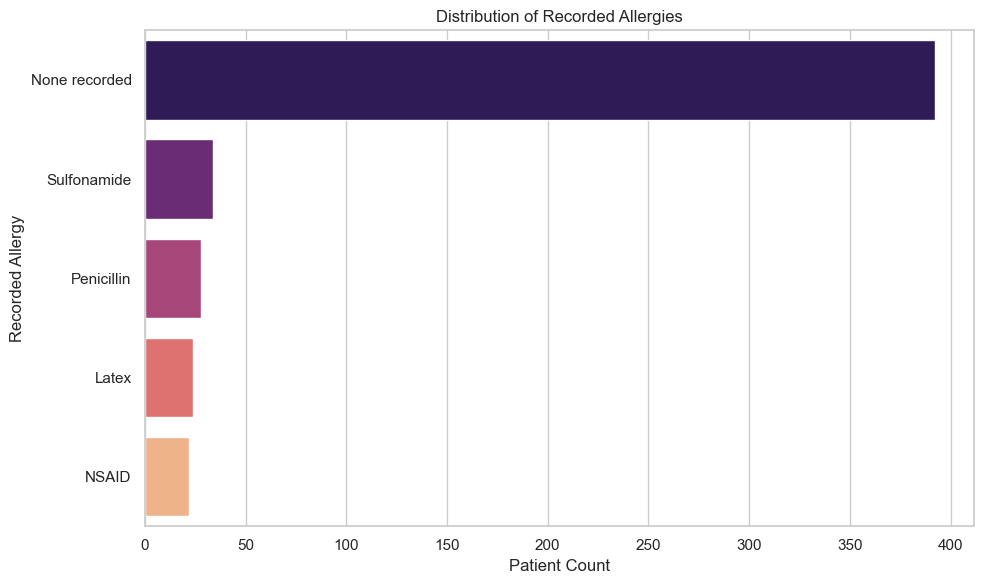

In [13]:
allergy_counts = (
    eda_df["recorded_allergy"]
    .value_counts()
    .reset_index()
)

allergy_counts.columns = ["recorded_allergy", "patient_count"]

allergy_counts

plt.figure(figsize=(10, 6))

sns.barplot(
    data=allergy_counts,
    x="patient_count",
    y="recorded_allergy",
    hue="recorded_allergy",
    palette="magma",
    legend=False
)

plt.title("Distribution of Recorded Allergies")
plt.xlabel("Patient Count")
plt.ylabel("Recorded Allergy")

plt.tight_layout()
plt.show()

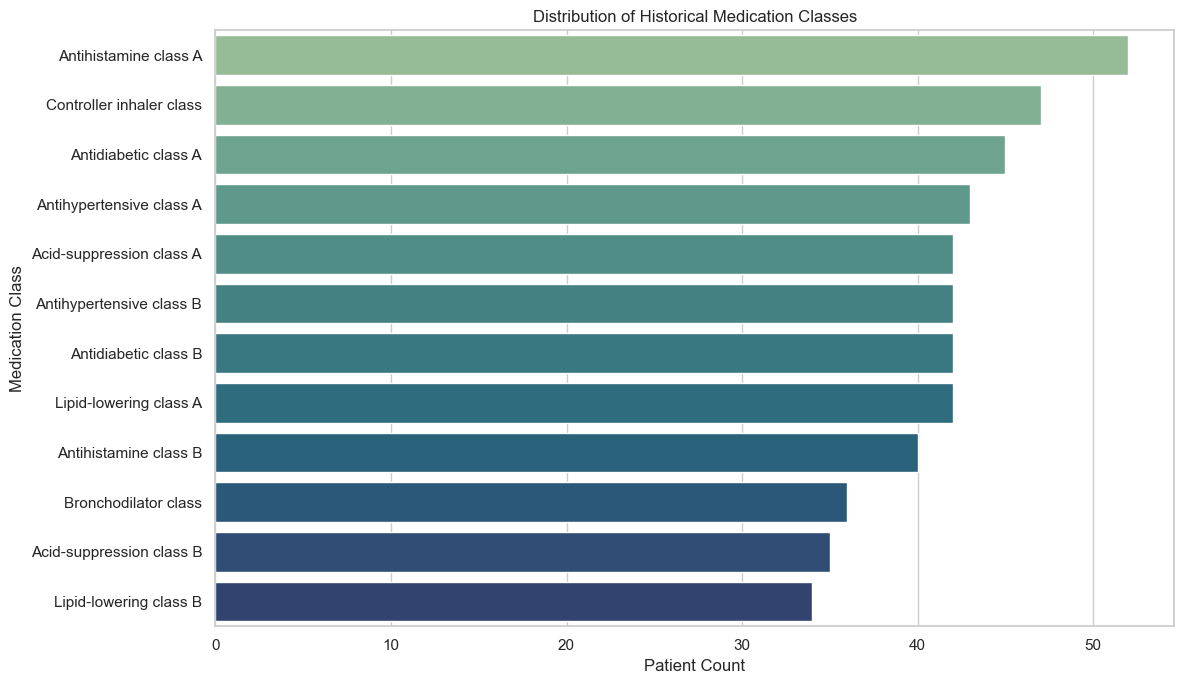

In [14]:
medication_counts = (
    eda_df["historical_medication_class"]
    .value_counts()
    .reset_index()
)

medication_counts.columns = [
    "historical_medication_class",
    "patient_count"
]

medication_counts

plt.figure(figsize=(12, 7))

sns.barplot(
    data=medication_counts,
    x="patient_count",
    y="historical_medication_class",
    hue="historical_medication_class",
    palette="crest",
    legend=False
)

plt.title("Distribution of Historical Medication Classes")
plt.xlabel("Patient Count")
plt.ylabel("Medication Class")

plt.tight_layout()
plt.show()

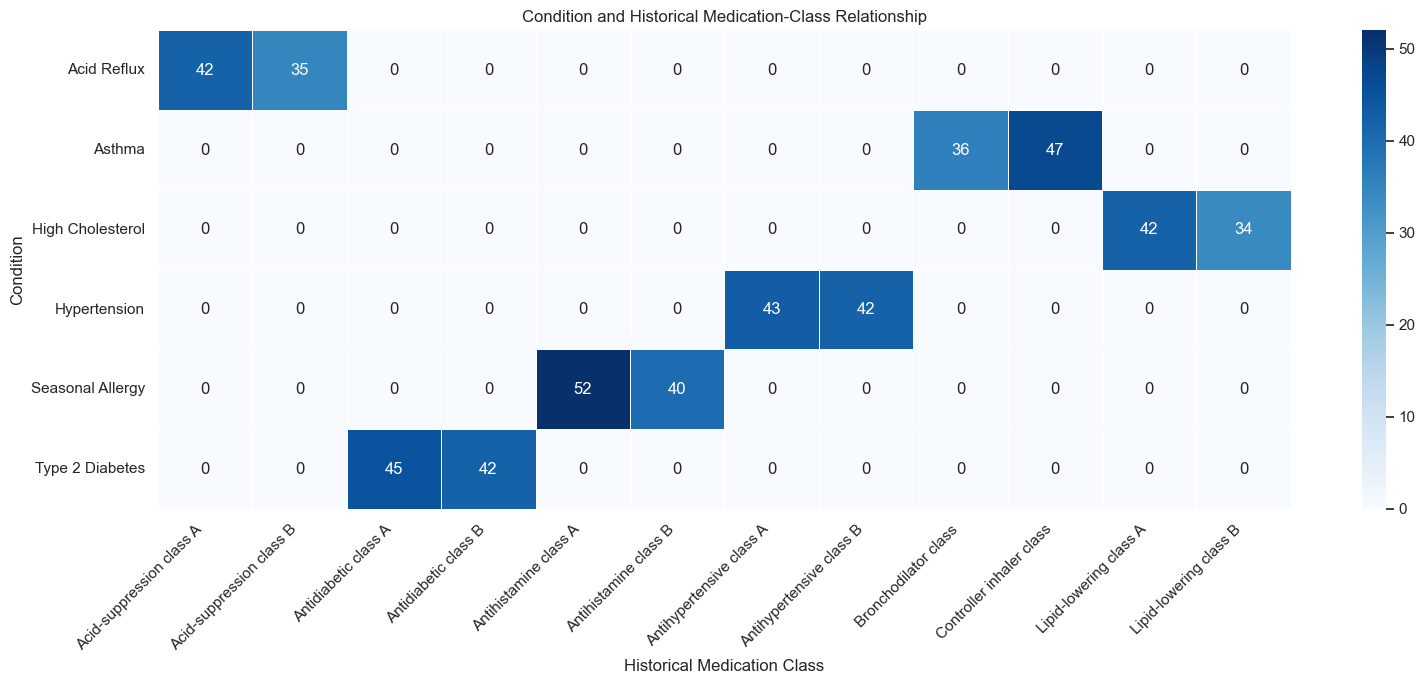

In [15]:
condition_medication = pd.crosstab(
    eda_df["condition"],
    eda_df["historical_medication_class"]
)

condition_medication

plt.figure(figsize=(16, 7))

sns.heatmap(
    condition_medication,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Condition and Historical Medication-Class Relationship")
plt.xlabel("Historical Medication Class")
plt.ylabel("Condition")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

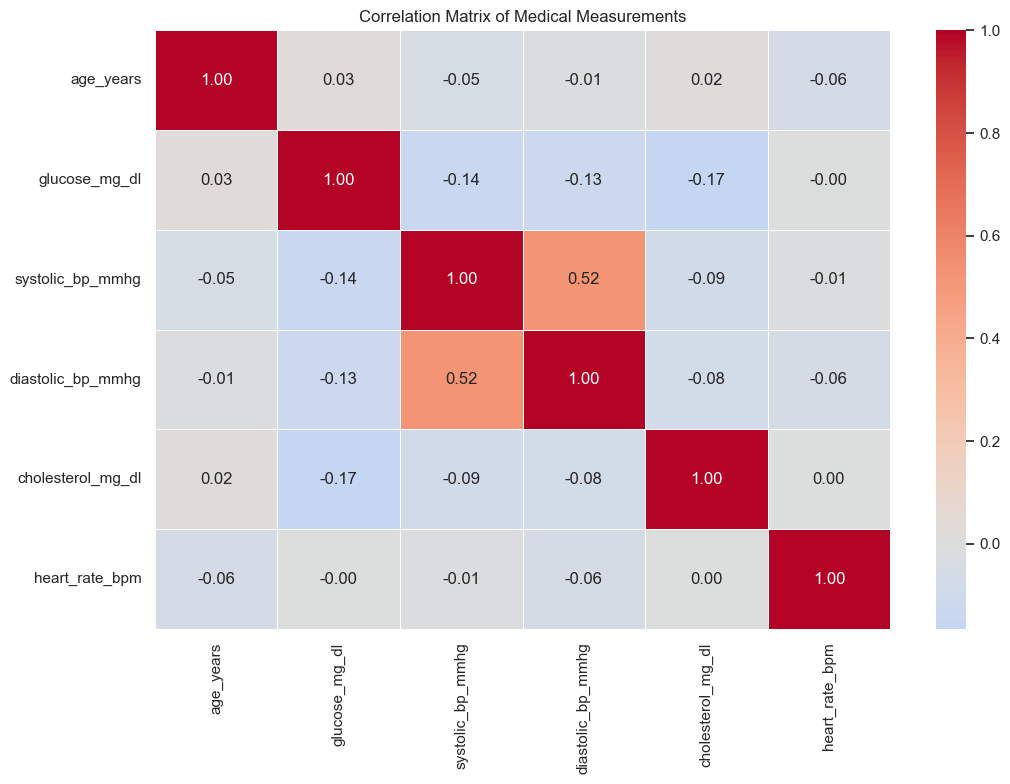

In [16]:
correlation_matrix = eda_df[numeric_columns].corr()

correlation_matrix.round(2)

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Medical Measurements")

plt.tight_layout()
plt.show()

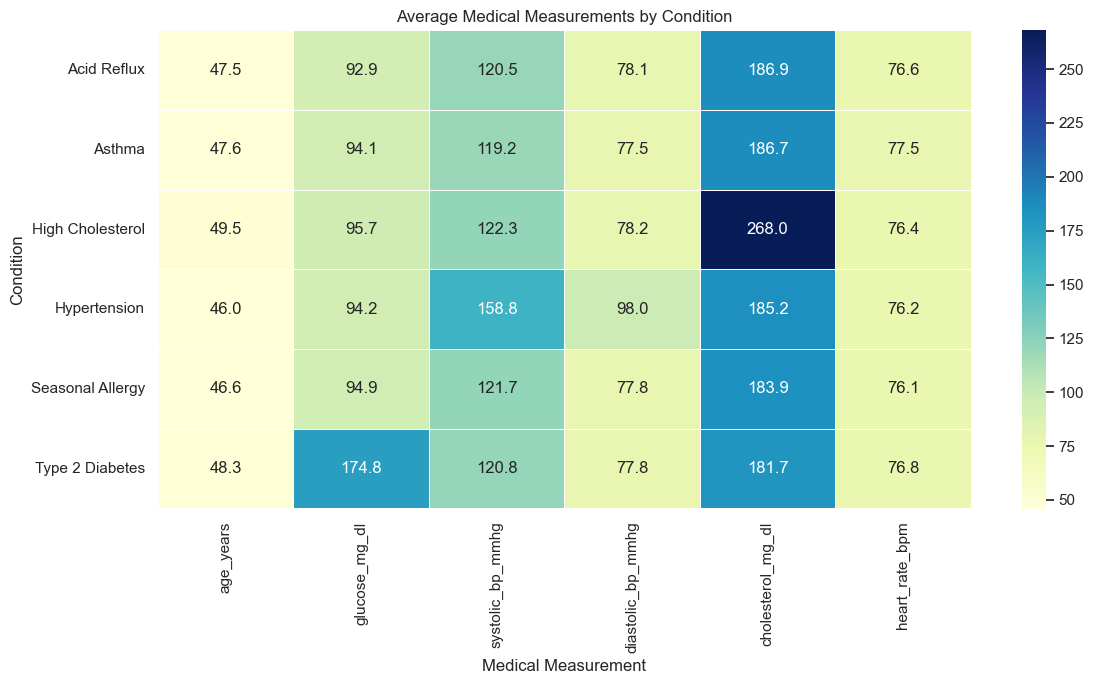

In [17]:
condition_summary = (
    eda_df
    .groupby("condition")[numeric_columns]
    .mean()
    .round(2)
)

condition_summary

plt.figure(figsize=(12, 7))

sns.heatmap(
    condition_summary,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Average Medical Measurements by Condition")
plt.xlabel("Medical Measurement")
plt.ylabel("Condition")

plt.tight_layout()
plt.show()

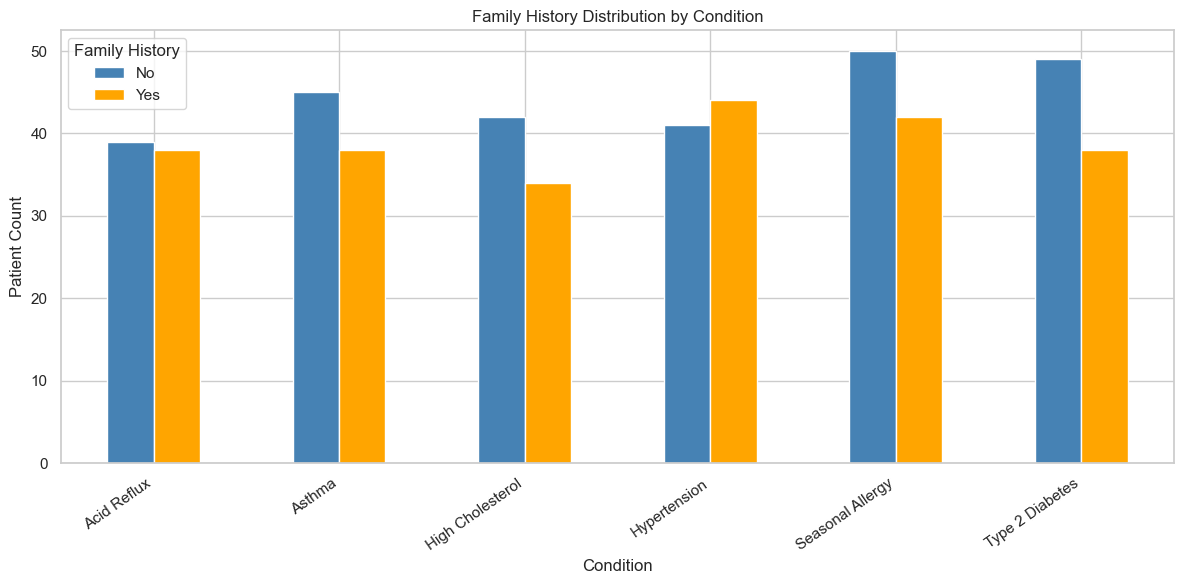

In [18]:
family_condition = pd.crosstab(
    eda_df["condition"],
    eda_df["family_history"]
)

family_condition

family_condition.plot(
    kind="bar",
    figsize=(12, 6),
    color=["steelblue", "orange"]
)

plt.title("Family History Distribution by Condition")
plt.xlabel("Condition")
plt.ylabel("Patient Count")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Family History")

plt.tight_layout()
plt.show()

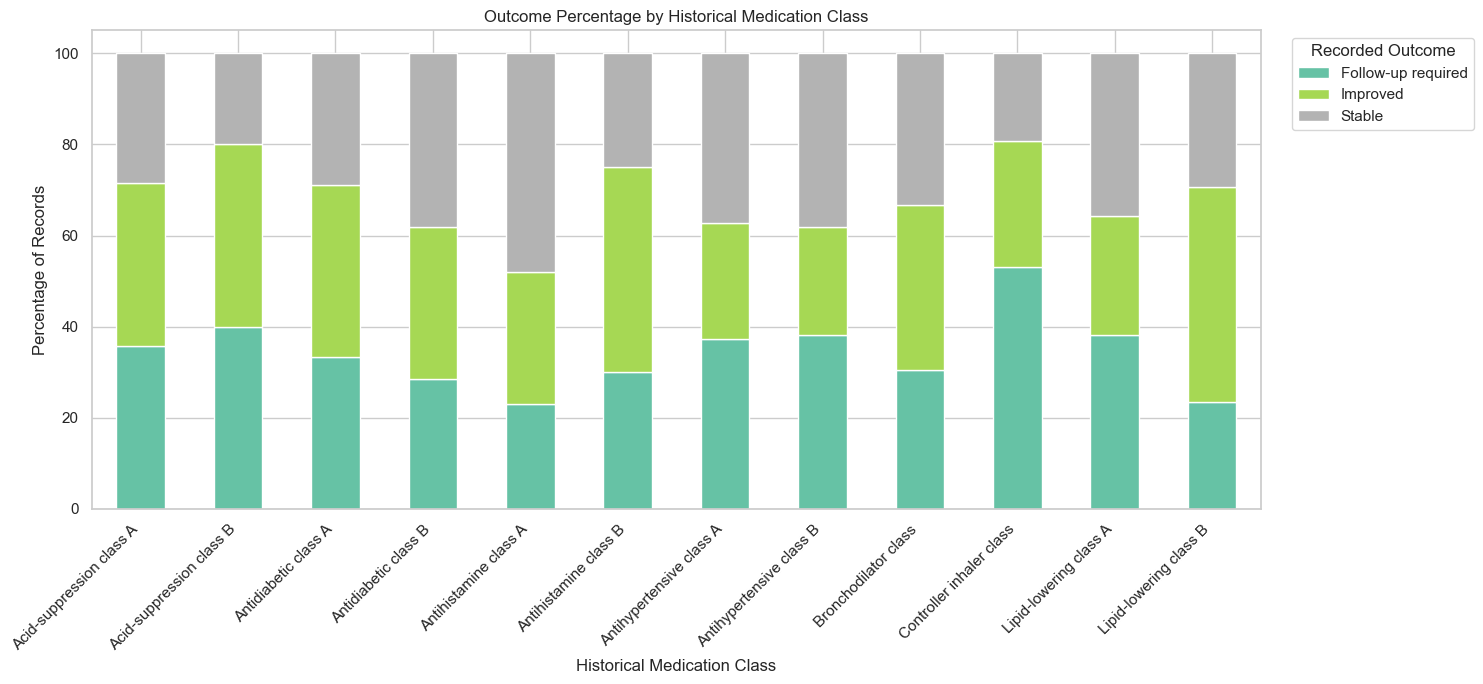

In [19]:
medication_outcome_percentage = pd.crosstab(
    eda_df["historical_medication_class"],
    eda_df["recorded_outcome"],
    normalize="index"
).mul(100).round(2)

medication_outcome_percentage

medication_outcome_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(15, 7),
    colormap="Set2"
)

plt.title("Outcome Percentage by Historical Medication Class")
plt.xlabel("Historical Medication Class")
plt.ylabel("Percentage of Records")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Recorded Outcome", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

In [20]:
eda_output_file = "healthcare_eda_results.xlsx"

with pd.ExcelWriter(eda_output_file, engine="openpyxl") as writer:
    eda_df.describe().T.to_excel(
        writer,
        sheet_name="Numeric_Summary"
    )

    condition_counts.to_excel(
        writer,
        sheet_name="Condition_Counts",
        index=False
    )

    outcome_counts.to_excel(
        writer,
        sheet_name="Outcome_Counts",
        index=False
    )

    adherence_outcome_percentage.to_excel(
        writer,
        sheet_name="Adherence_Outcome"
    )

    condition_outcome.to_excel(
        writer,
        sheet_name="Condition_Outcome"
    )

    condition_medication.to_excel(
        writer,
        sheet_name="Condition_Medication"
    )

    correlation_matrix.to_excel(
        writer,
        sheet_name="Correlations"
    )

    condition_summary.to_excel(
        writer,
        sheet_name="Condition_Summary"
    )

print("EDA results saved as:", eda_output_file)

EDA results saved as: healthcare_eda_results.xlsx
